In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# Reading a triangular diagram (Illustration 11.2-7)

This notebook works **Illustration 11.2-7**: one kilogram of a 50/50 mixture of A and
B is mixed with two kilograms of a mixture that is 15 % A, 5 % B and 80 % C, and the
question is where the product sits on a triangular diagram. There is no
thermodynamics in it at all -- no equilibrium, no activity coefficient, no model.
It is three mass balances and a picture.

**Which is exactly why it gets a notebook.** Everything else this chapter does
with a triangular diagram -- the extraction of Illustration 11.2-8, the two-stage
cascade of 11.2-9, every tie line on Fig. 11.2-8 -- rests on the one geometric fact
this illustration demonstrates: **mixing two streams puts the product on the straight
line between them, at the point that divides it in inverse proportion to the
amounts.** That is the lever rule, and it is a consequence of the mass balances being
linear, not of anything thermodynamic.

The notebook computes the balance, draws the illustration's figure, and then checks
the lever rule numerically rather than asserting it.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:

import sys; sys.path.insert(0, "..")
import os
import numpy as np
import matplotlib.pyplot as plt

from thermo.charts import use_book_style
from thermo import ternary
from thermo.lle import mix_streams

use_book_style()

# The two feeds, as weight fractions of (A, B, C), and their masses in kg.
FEED_1 = np.array([0.50, 0.50, 0.00])     # 1 kg of the binary A + B
FEED_2 = np.array([0.15, 0.05, 0.80])     # 2 kg of the ternary
MASSES = [1.0, 2.0]

total, product = mix_streams(MASSES, [FEED_1, FEED_2])

print("  (a) the species balances, in kilograms")
for name, i, printed in (("A", 0, 0.8), ("B", 1, 0.6), ("C", 2, 1.6)):
    kg = MASSES[0] * FEED_1[i] + MASSES[1] * FEED_2[i]
    print(f"    {name}: {FEED_1[i]:.2f} x {MASSES[0]:.0f} + {FEED_2[i]:.2f} x"
          f" {MASSES[1]:.0f} = {kg:.1f} kg        SIS {printed}")

print(f"\n    total = {total:.0f} kg, and the three add to"
      f" {sum(MASSES[0]*FEED_1 + MASSES[1]*FEED_2):.1f} kg")
print("\n  the final composition")
for name, i, printed in (("A", 0, 26.7), ("B", 1, 20.0), ("C", 2, 53.3)):
    print(f"    {name}: {product[i]:.4f} weight fraction = {100*product[i]:.1f} wt %"
          f"        SIS {printed}")

assert np.isclose(product.sum(), 1.0)
print(f"\n  The species masses sum to the {total:.0f} kg the overall balance requires,")
print("  which is the check the illustration itself makes.")

  (a) the species balances, in kilograms
    A: 0.50 x 1 + 0.15 x 2 = 0.8 kg        SIS 0.8
    B: 0.50 x 1 + 0.05 x 2 = 0.6 kg        SIS 0.6
    C: 0.00 x 1 + 0.80 x 2 = 1.6 kg        SIS 1.6

    total = 3 kg, and the three add to 3.0 kg

  the final composition
    A: 0.2667 weight fraction = 26.7 wt %        SIS 26.7
    B: 0.2000 weight fraction = 20.0 wt %        SIS 20.0
    C: 0.5333 weight fraction = 53.3 wt %        SIS 53.3

  The species masses sum to the 3 kg the overall balance requires,
  which is the check the illustration itself makes.


## Part (b): the figure, and the lever rule that is hiding in it

The three points are plotted below. The product does not merely happen to fall between
the two feeds -- it falls **on the straight line joining them**, and it divides that
line in the ratio of the *other* stream's mass:

$$\frac{\overline{z\,c_1}}{\overline{z\,c_2}} = \frac{m_2}{m_1}$$

so with 1 kg of the first feed and 2 kg of the second, the product sits **twice as far**
from feed 1 as from feed 2. Reading a triangular diagram is reading that ratio off a
ruler, which is why an extraction problem can be solved with a straightedge.

The check below measures the two distances rather than assuming them.

In [3]:

xy1, xy2, xyz = ternary.to_xy(FEED_1), ternary.to_xy(FEED_2), ternary.to_xy(product)
d1 = float(np.hypot(*(xyz - xy1)))
d2 = float(np.hypot(*(xy2 - xyz)))
_u, _v = xy2 - xy1, xyz - xy1
cross = float(_u[0] * _v[1] - _u[1] * _v[0])   # the 2-D cross product

print("  Is the product on the line joining the two feeds?")
print(f"    cross product of (feed2 - feed1) with (product - feed1) = {cross:.2e}")
print("    zero to machine precision, so the three points are collinear.")
print("\n  The lever rule, measured on the diagram:")
print(f"    distance feed 1 -> product : {d1:.4f}")
print(f"    distance product -> feed 2 : {d2:.4f}")
print(f"    ratio = {d1/d2:.3f}, against the mass ratio m2/m1 = {MASSES[1]/MASSES[0]:.3f}")

  Is the product on the line joining the two feeds?
    cross product of (feed2 - feed1) with (product - feed1) = 2.78e-17
    zero to machine precision, so the three points are collinear.

  The lever rule, measured on the diagram:
    distance feed 1 -> product : 0.4631
    distance product -> feed 2 : 0.2315
    ratio = 2.000, against the mass ratio m2/m1 = 2.000


  label collisions: none
  text below 7 pt: none


  wrote pdf/Illustration_11.2-7.pdf


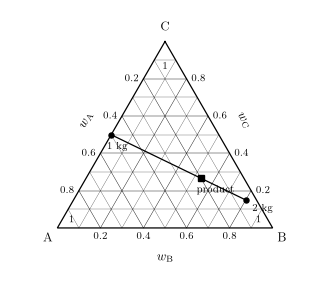

In [4]:
# --- Print art: Illustration 11.2-7's triangular diagram --------------------
#   pdf/Illustration_11.2-7.pdf -> deliverables/figures/print-bw/ch11/c11uf004.pdf
#
# The printed art shows the three compositions and the line through them. Nothing here is
# measured, so there is no data to be faithful to -- what the drawing has to get right
# is the geometry, and the collinearity check above is what says it does.
fig, ax = plt.subplots(figsize=(3.4, 3.1))
ternary.ternary_axes(ax, top="C", left="A", right="B", ticks=0.2, minors=2,
                     symbol="w")

# The mixing line first, so the markers sit on top of it.
line = np.array([ternary.to_xy(FEED_1), ternary.to_xy(FEED_2)])
ax.plot(line[:, 0], line[:, 1], "-", color="k", lw=0.9)

# The labels are short and all three sit below their markers. Longer ones ("1 kg
# feed") collide with the tick numbers and the w_A edge label, and the remedy for
# a label that does not fit is a shorter label, never smaller type.
ternary.point(ax, FEED_1, "1 kg", marker="o", ms=3.6, offset=(-0.02, -0.075))
ternary.point(ax, FEED_2, "2 kg", marker="o", ms=3.6, offset=(0.03, -0.06))
ternary.point(ax, product, "product", marker="s", ms=3.8, offset=(-0.02, -0.075))

# The gate every staged ch11 figure passes: nothing below 7 pt, no overlapping text.
fig.canvas.draw()
rend = fig.canvas.get_renderer()
boxes = [(t.get_text(), t.get_window_extent(renderer=rend)) for t in ax.texts
         if t.get_text().strip()]
clash = [(a, b) for i, (a, ba) in enumerate(boxes) for b, bb in boxes[i + 1:]
         if ba.overlaps(bb)]
print("  label collisions:", clash if clash else "none")
assert not clash
small = [(t.get_text(), t.get_fontsize()) for t in ax.texts if t.get_fontsize() < 7]
print("  text below 7 pt:", small if small else "none")
assert not small

os.makedirs("pdf", exist_ok=True)
fig.tight_layout()
fig.savefig("pdf/Illustration_11.2-7.pdf", dpi=300, bbox_inches="tight")
print("  wrote pdf/Illustration_11.2-7.pdf")
plt.show()

## Why this small illustration carries the chapter

The Comment after Illustration 11.2-7 makes the point in one sentence: the product is
on a straight line between the feeds *because the mass balances are linear equations*.
Nothing about phase equilibrium was used to get there, and that is what makes the
result so useful later:

- In **Illustration 11.2-8** the same construction locates the feed point of an
  extraction -- solvent plus feed -- before any equilibrium is imposed. The tie line
  through that point is where the thermodynamics enters, and only there.
- In **Illustration 11.2-9** it runs twice, once per stage.
- Every **tie line** on Fig. 11.2-8 is the same lever rule read backwards: the two ends
  are phases in equilibrium, and the overall composition between them fixes how much of
  each there is.

So a triangular diagram does two different jobs on one sheet of paper. The **dome** is
measured thermodynamics and has to come from experiment. The **straight lines** are
arithmetic and would be there for any three components that do not react.

## Your turn

1. Mix 1 kg of feed 1 with 5 kg of feed 2 instead of 2 kg. Where does the product move
   to, and what happens to the lever ratio? Confirm that the product always lies on the
   same straight line no matter what the amounts are.
2. What amounts of the two feeds would give a product containing exactly 40 wt % C?
   Solve it as a mass balance, then read your answer off the diagram with a ruler and
   see how close you get.
3. The product of this illustration is assumed not to phase split. Overlay the MIK +
   acetone + water dome from `ternary_extraction_MIK_acetone_water_example.ipynb` and
   find out whether a product at 26.7 / 20.0 / 53.3 would in fact be one phase or two,
   if A, B and C were MIK, acetone and water.
4. Three streams are mixed rather than two. Show, by extending the argument above, that
   the product lies inside the triangle whose vertices are the three feeds -- and find
   where.
5. `ternary.to_xy` maps a composition to a point in the plane. Read its source and work
   out why the mapping has to be linear for the lever rule to be readable with a ruler.